**Hidden Markov Model**

Paulo Yoshio Kuga

In this notebook, we are going to show how to train the HMM model with lissa.

In [1]:
#import libraries

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

from sklearn.mixture import GaussianMixture

In [2]:
#You also can read data without processing it always:

totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
totalData.rename(columns={"index":"time"},inplace=True)
totalData.drop(columns=["Unnamed: 0"],inplace=True)

/tmp/ipykernel_249648/2621100290.py:3: DtypeWarning: Columns (16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


Then, a list of properties is obtained through copy and paste of previous $list(entireData)$

In [3]:
Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP Current Module',
    #'ESP Vibration X',
    #'ESP Vibration Y',
    'ESP Vibration Module'
    #'ESP Power',
    #"Well_down"
    ]

pumpList = totalData["Well Run"].unique()

In [4]:
mainSeed = 19971215
np.random.seed(mainSeed)

totalData["Choke Closed"] = 1-totalData["Choke Opening"]
totalData["Radius"] = totalData[Headers].pow(2).sum(axis=1).pow(1/2)

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()

totalData["boxcox"] = pt.fit_transform(totalData["Radius"].to_numpy().reshape(-1,1))

X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=totalData)

/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/ml.py:258: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.figure.show()


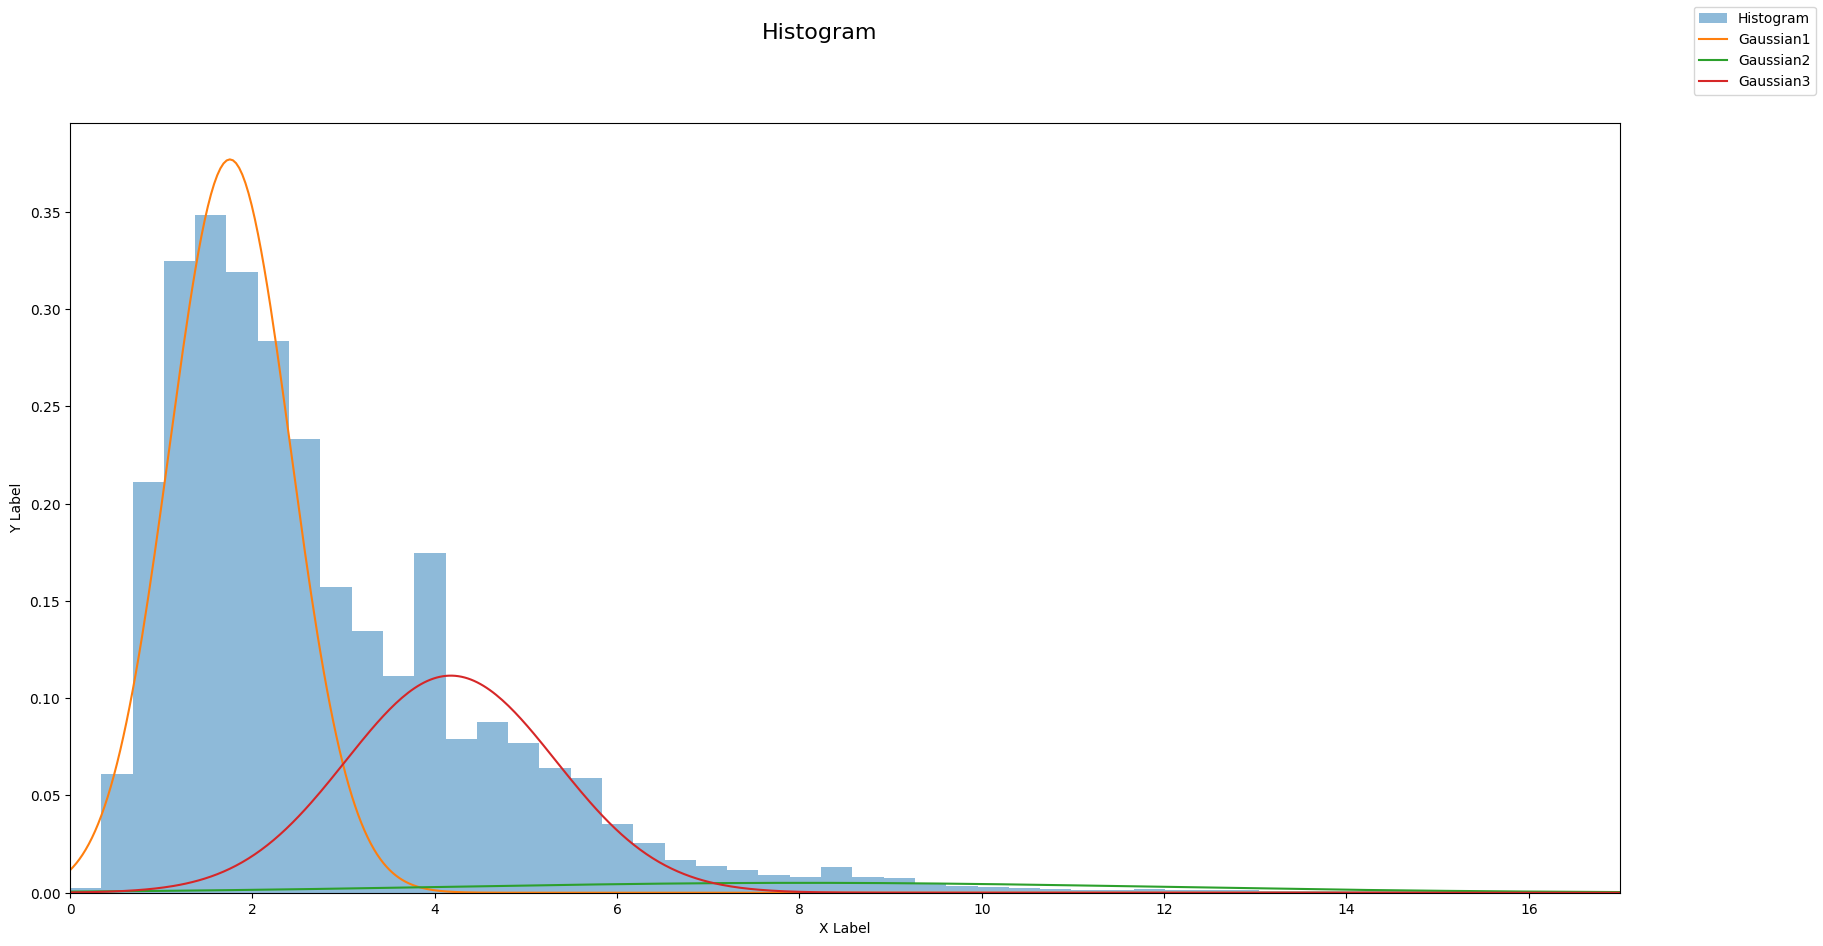

In [5]:
n = 3
radiusData = X_train["Radius"].loc[X_train["Well_down"]==0]

model = li.GaussianMixtureModel(radiusData,n_components=n,random_state=mainSeed)

model.plot_gmm()
# li.GaussianMixturePlot(radiusData,model,[
#     "Histograma da norma euclidiana do Z-score",
#     "Gaussiana Interpolada",
#     "Ajuste do modelo GMM para a distribuição da norma euclidiana do Z-score",
#     "Valores da norma",
#     "Densidade"],
#     figsize=(10,5),
#     limits=(0,17))

# print(model.weights_)

#li.PostProcessing(model, totalData, modelData,"Radius", "State GMM Radius", totalLength)

In [17]:
modelRadius = hmm.GaussianHMM(
    n_components=n,
    random_state=mainSeed,
    covariance_type="full",
    #params="st",
    init_params="st",
    algorithm="viterbi"
    )

modelRadius.means_ = model.means_
modelRadius.covars__ = model.covariances_


modelRadius = li.HMMTrainer(X_train["Radius"],trainLength,modelRadius)

li.PostProcessing(modelRadius, totalData, modelData,"Radius", "State Radius", totalLength)
print(modelRadius.get_stationary_distribution())
totalData["State Radius"] = totalData["State Radius"].map(li.StateConversion(modelRadius.get_stationary_distribution(),n))


AIC: 1440449.256407113 BIC: 1440606.0417109558
[0.73247631 0.16029933 0.10722436]


In [ ]:
numpy_array = totalData["Radius"].to_numpy().reshape(-1,1)


log_np = model.score_samples(numpy_array)
prob = np.exp(log_np)

totalData["entropy"] = -log_np*prob

# (1-totalData["entropy"])

Text(0.5, 59.12222222222219, 'Tempo')

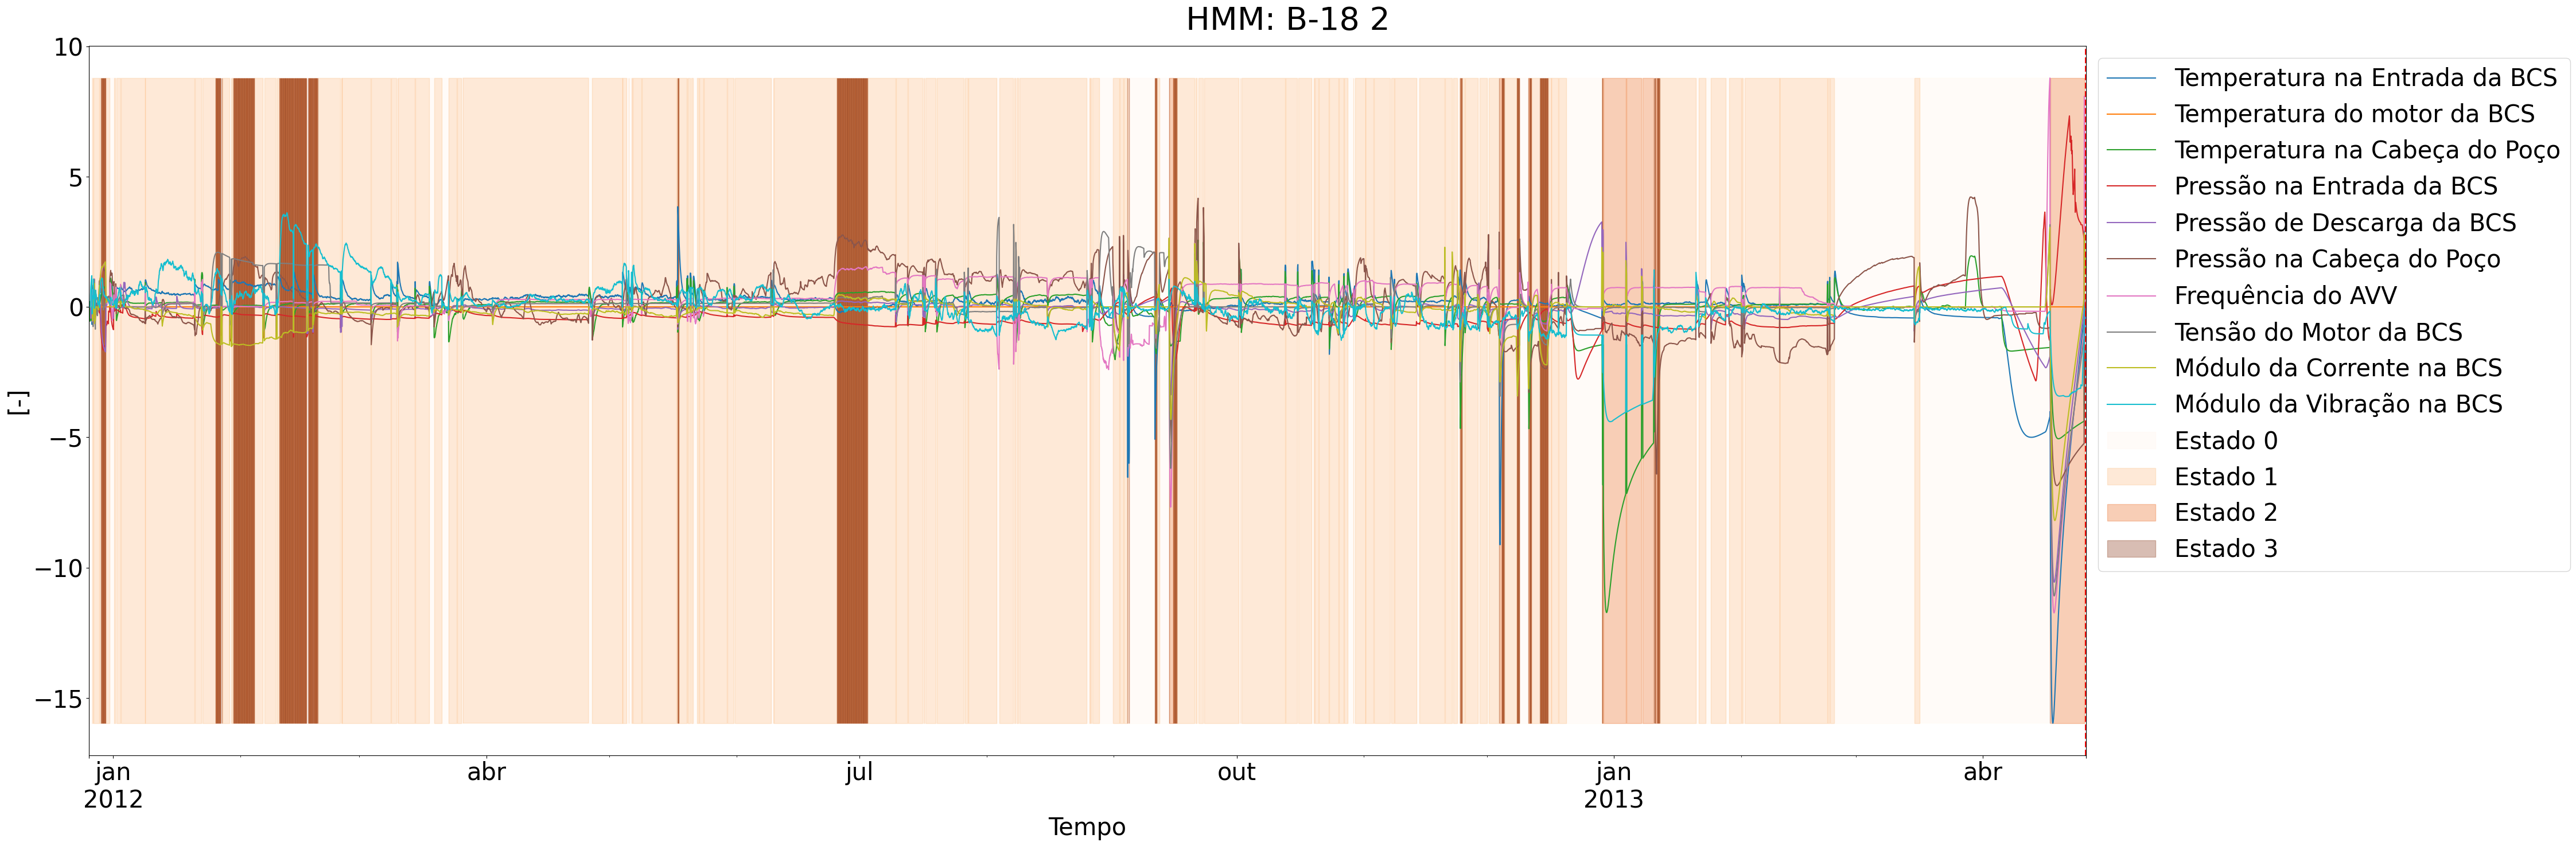

In [18]:
pump = pumpList[0]

#b-18 2
#a-12 2
#a-29 2

pumpData = totalData.loc[totalData["Well Run"]==pump].copy()

pumpData["time"] = pd.to_datetime(pumpData["time"])
pumpData.set_index("time",inplace=True)
pumpData = pumpData.asfreq('h',fill_value=0)
    

fig,axs = li.HMMPicture(pumpData,pump,Headers=Headers,measures='[-]',states="State Radius", numberOfStates=n, figsize=(45,15),english=False,gnrlFont=30,titleFont=40)
axs.set_xlabel("Tempo")



#fig.savefig("../imagens_gerais/pumps/"+pump+"markovrun.jpg")


<Axes: xlabel='time'>

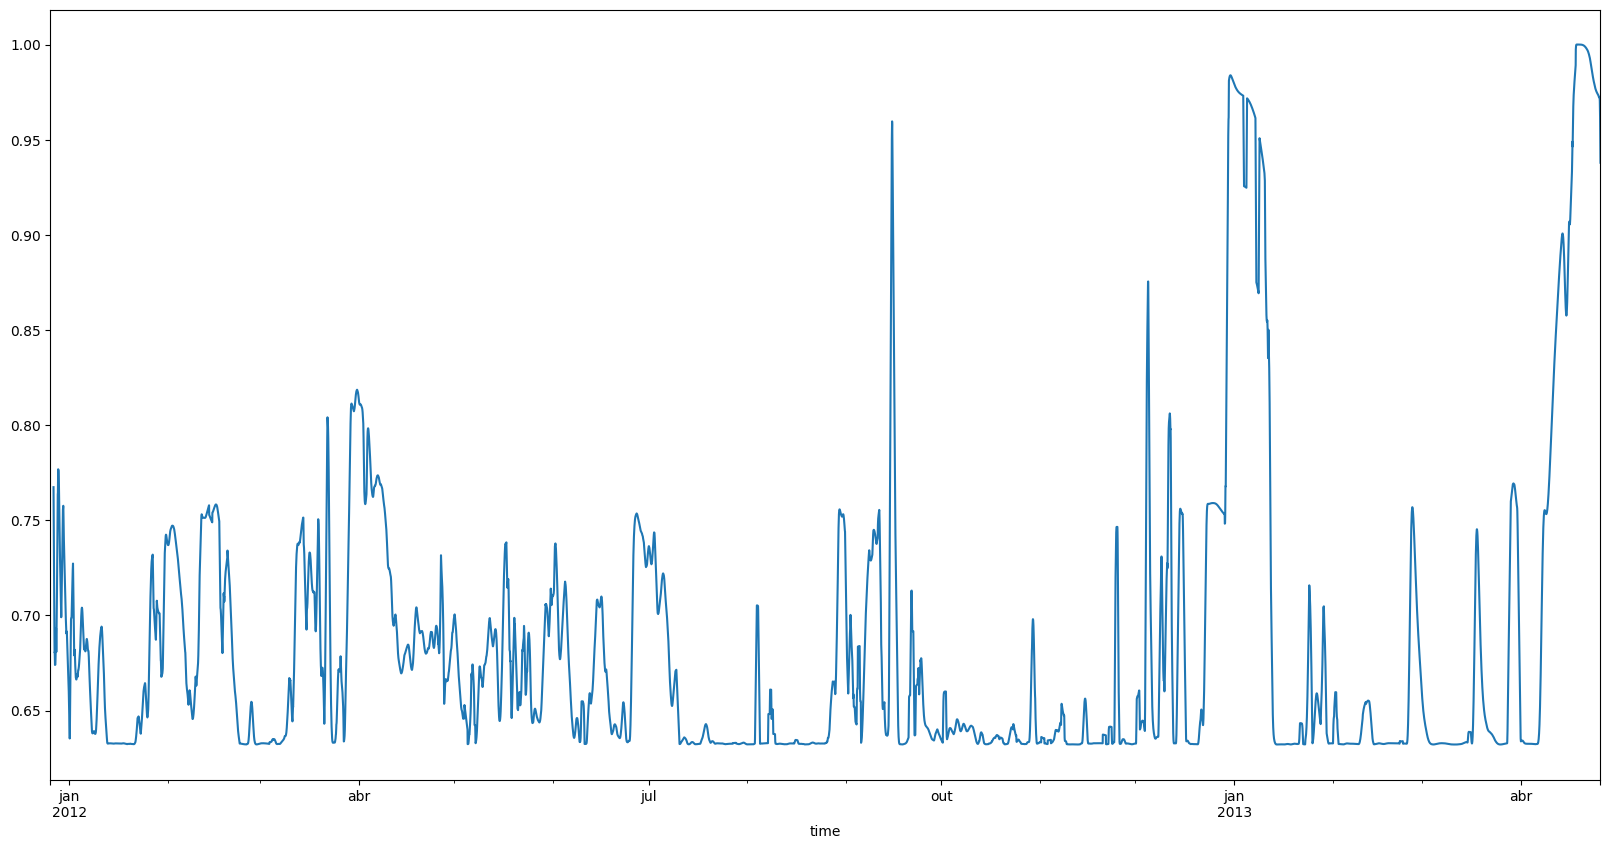

In [10]:
(1-pumpData["entropy"]).rolling(24).mean().plot(figsize=(20,10))

In [ ]:
for pump in pumpList:
    pumpData = totalData.loc[totalData["Well Run"]==pump].copy()
    pumpData["time"] = pd.to_datetime(pumpData["time"])
    pumpData.set_index("time",inplace=True)
    pumpData = pumpData.asfreq('h',fill_value=0)
    
    fig,axs = li.HMMPicture(pumpData,pump,Headers=Headers,measures='[-]',states="State Radius", numberOfStates=n, figsize=(45,15),english=False,gnrlFont=30,titleFont=40)
    plt.rcParams["font.size"]=20
    axs.set_xlabel("Tempo")

    fig.savefig("../imagens_gerais/pumps/"+pump+"markovrun.jpg")
    plt.close()

In [ ]:
falhas = np.array([])
for pump in pumpList:#
    pumpData = totalData.loc[(totalData["Well Run"]==pump) & (totalData["Well_down"]==0) ]#.copy()
    
    last = pumpData.shape[0]
    idx = (pumpData["Failure"]==True).diff()
    idx.iloc[0] = False

    if idx.sum()!=0:
        dif = pumpData.index[last-1]-pumpData["time"].loc[idx].index[0]
        falhas = np.append(falhas,dif)

    

In [ ]:
(falhas > 3).sum()/falhas.shape[0]

0.575

In [ ]:
medianListR = np.array([])

for pump in X_test["Well Run"].unique():#pumpList:#
    pumpData = totalData.loc[(totalData["Well Run"]==pump) & (totalData["Well_down"]==0) ]#.copy()
    last = pumpData.shape[0]
    pumpMedianR = pumpData.loc[pumpData.index[last-24:last-1],"State Radius"].median()
    medianListR = np.append(medianListR,pumpMedianR)




In [ ]:
counts[[1,2]]

array([22, 16])

In [ ]:
counts[2]/counts.sum()

0.2807017543859649

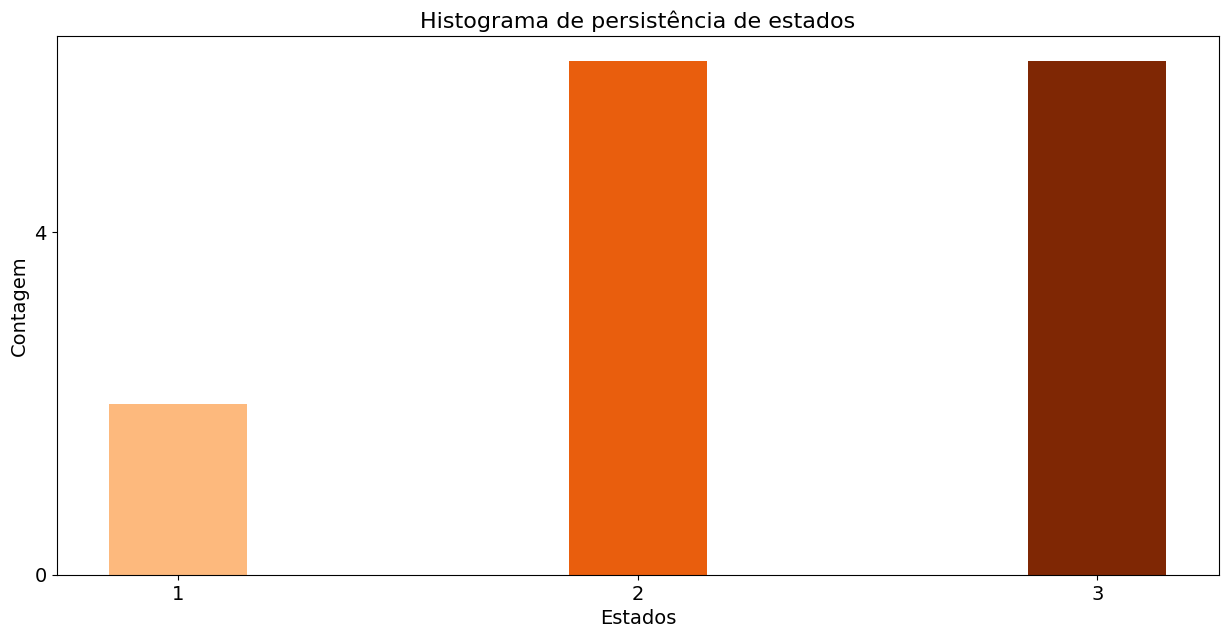

In [ ]:
cmap = plt.get_cmap('Oranges', n+1)
plt.rcParams["font.size"] = 14
fig,axs=plt.subplots(1,1,figsize=(15,7))
states,counts = np.unique(medianListR,return_counts=True)
axs.bar(states,counts,width=0.3,color=[cmap(i) for i in range(1,cmap.N)])
axs.set_xticks(states,np.int64(states))
axs.set_yticks(range(int(0), int(max(counts))+1,4))
axs.set_ylabel("Contagem")
axs.set_xlabel("Estados")
axs.set_title("Histograma de persistência de estados",fontsize=16)


plt.savefig("../imagens_gerais/radius_histogram_xtest.jpg")

In [ ]:
counts

array([2, 6, 6])

In [ ]:
model.weights_

array([0.63381229, 0.31874   , 0.04744771])

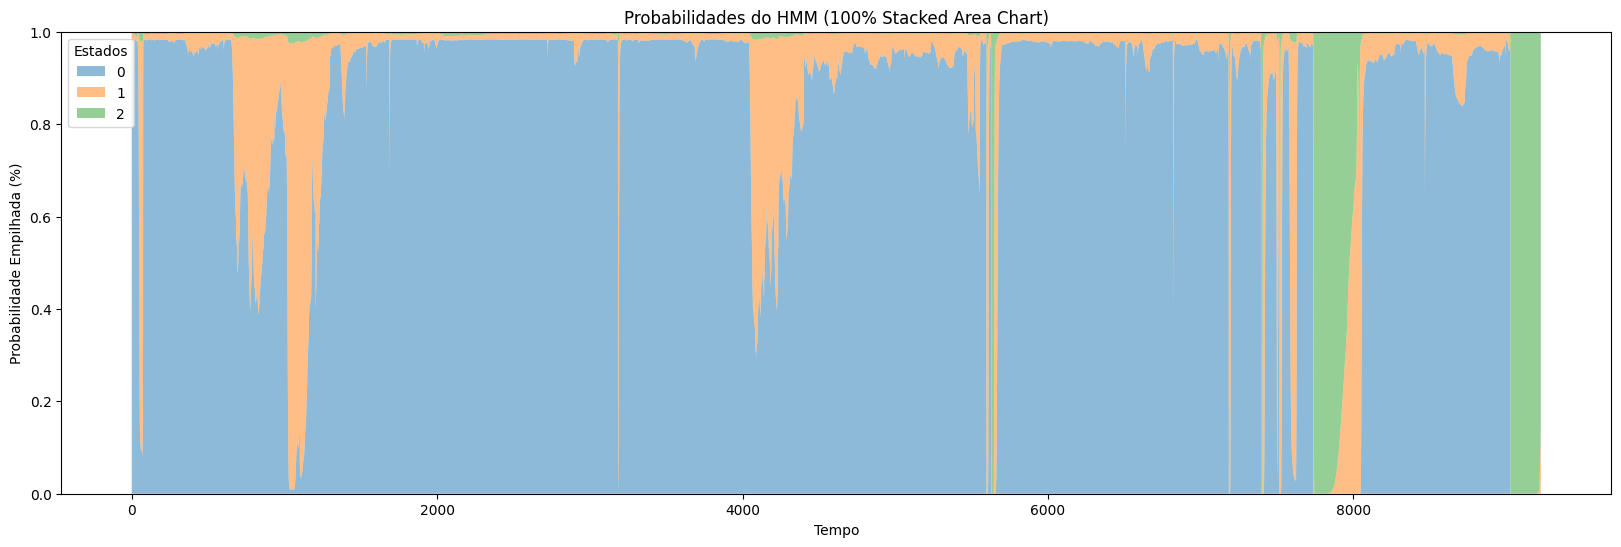

In [ ]:
li.PlotHMMProbs(totalData["Radius"].loc[(totalData["Well_down"]==0) & (totalData["Well Run"]==pumpList[0])],model)

In [ ]:
from scipy.stats import chisquare

# Contagens das classes ao longo das inicializações
observed_counts = np.array([counts[0],counts[1]]) # Substituir pelos valores reais
expected_counts = np.array([1/2, 1/2]) * sum(observed_counts)

# Teste qui-quadrado de aderência
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
else:
    print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")


Estatística qui-quadrado: 0.0270, p-valor: 0.8694
Não há evidências suficientes para afirmar que C ocorre mais que o esperado.


In [ ]:
# cmap = plt.get_cmap('Oranges', n)
# plt.figure(figsize=(7,5))

# states,counts = np.unique(medianListR,return_counts=True)
# plt.bar(states,counts,width=0.3, color=[cmap(i) for i in range(1,cmap.N)])
# plt.xticks(states,np.int64(states))
# plt.ylabel("Counts")
# plt.xlabel("States")
# plt.title("Vibration Modulus Persistence Histogram")
# plt.savefig("../imagens_gerais/vibration_histogram.jpg")

In [ ]:
# # Contagens das classes ao longo das inicializações
# observed_counts = counts  # Substituir pelos valores reais
# expected_counts = np.array([1/3, 1/3, 1/3]) * sum(observed_counts)

# # Teste qui-quadrado de aderência
# chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

# print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

# if p_value < 0.05:
#     print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
# else:
#     print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")


In [ ]:
for pump in pumpList:
   
    pumpData = totalData.loc[totalData["Well Run"]==pump].copy()

    # fig, axs =li.HMMPicture(
    #     pumpData,
    #     pump,
    #     props=[PCAHeaders,vibeHeader],
    #     states=["State Radius","State Mod"],
    #     numberOfStates=n,
    #     figsize=(40,15)
    #     )

    # fig.savefig("../imagensFinaisHMM/heatmap-"+pump+".png")
    # plt.close()
    onlineData = pumpData.loc[pumpData["Well_down"]==0]
    plt.figure(figsize=(10,10))
    plt.scatter(onlineData["Water Cut @ 20degC - 1 atm"],onlineData["Choke Closed"],c=onlineData["State Radius"],s=onlineData["Radius"])
    plt.xlabel("Water Cut @ 20degC - 1 atm")
    plt.ylabel("Choke Closed")
    plt.savefig("../choke_per_watercut/"+pump+".png")
    plt.close()


Text(0, 0.5, 'Choke Closed')

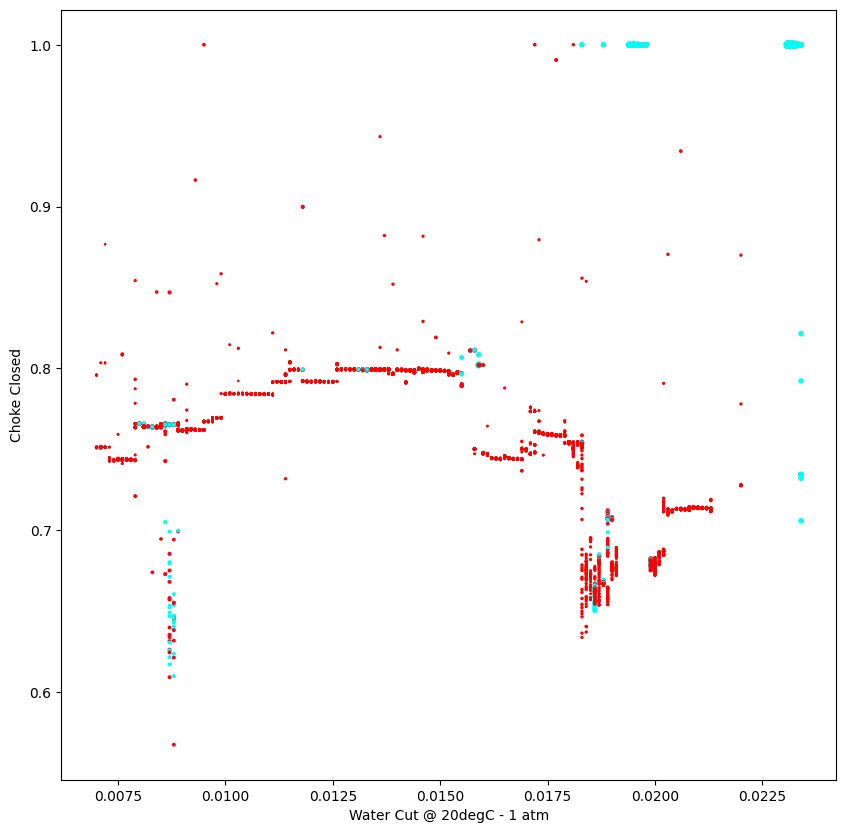

In [14]:
onlineData = totalData.loc[(totalData["Well_down"]==0) & (totalData["Well Run"]==pumpList[0]) ]

x = onlineData["Water Cut @ 20degC - 1 atm"]#.apply(np.exp))
y = onlineData["Choke Closed"]#.apply(np.exp))

plt.figure(figsize=(10,10))
plt.scatter(x,y,c=onlineData["State Radius"],s=onlineData["Radius"],cmap='hsv')
plt.xlabel("Water Cut @ 20degC - 1 atm")
plt.ylabel("Choke Closed")
# plt.savefig("../choke_per_watercut/"+pump+".png")
# plt.close()

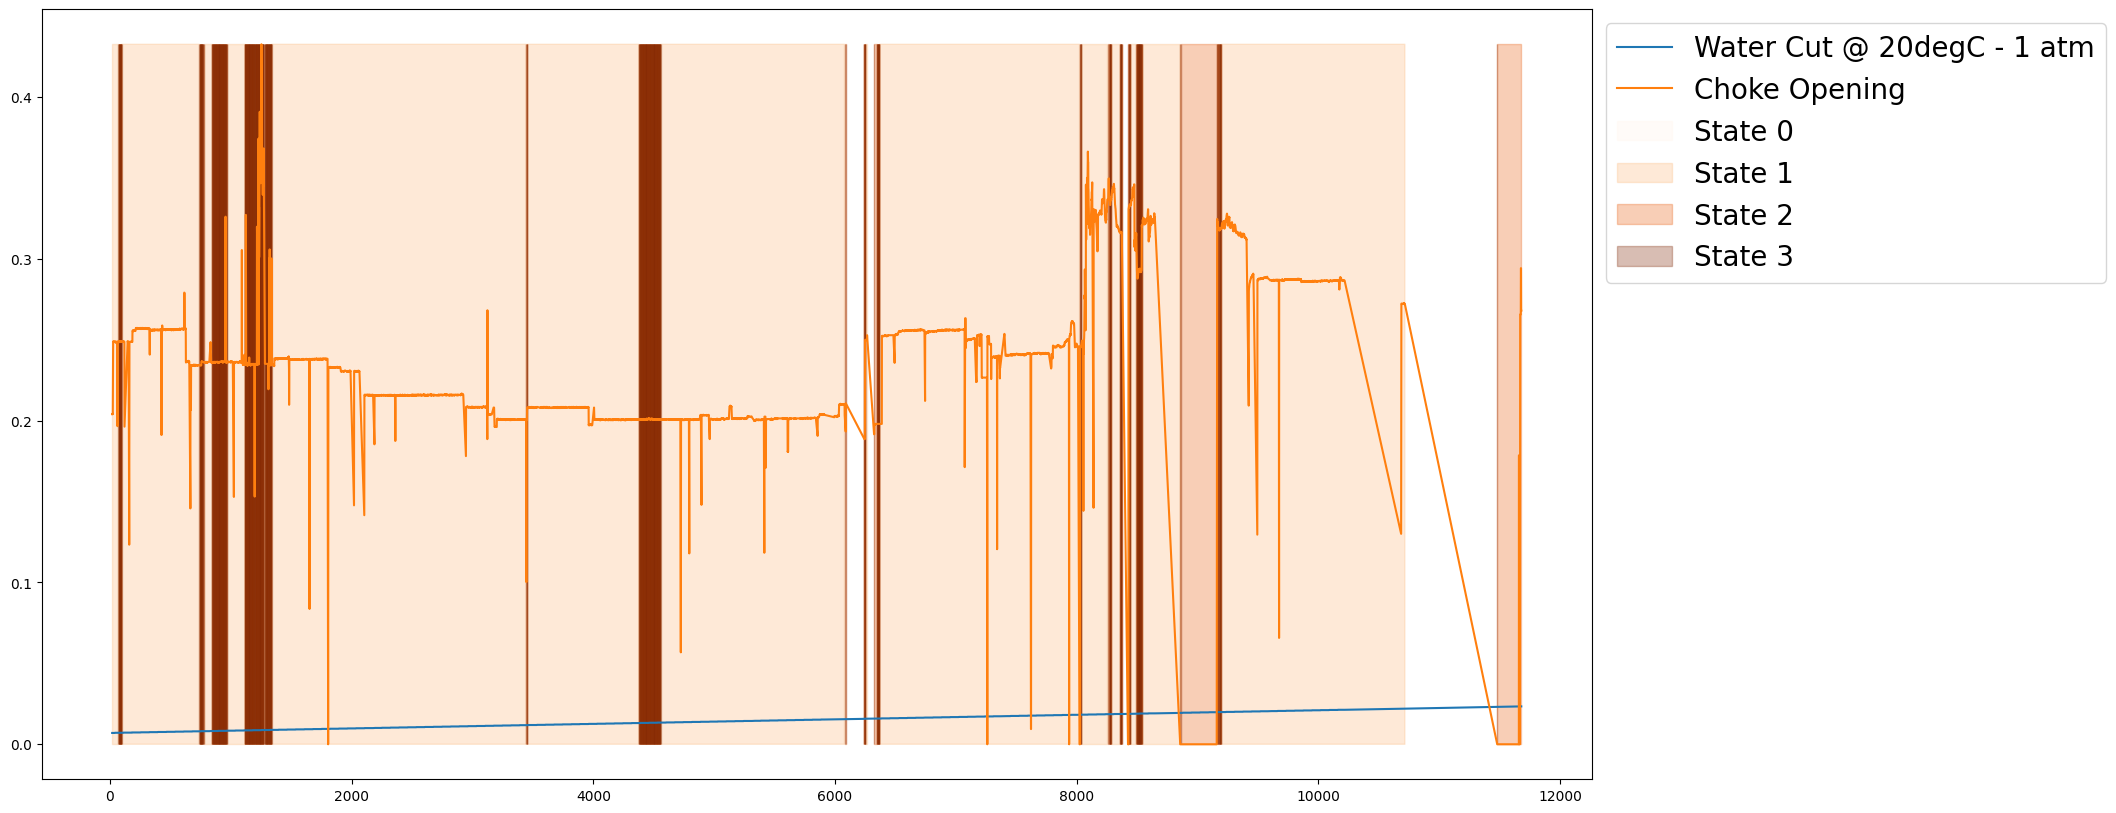

In [15]:
fig,axs = plt.subplots(1,1,figsize=(20,10))

onlineData[["Water Cut @ 20degC - 1 atm","Choke Opening"]].plot(ax=axs)
li.OverFill(onlineData,["Water Cut @ 20degC - 1 atm","Choke Opening"],"State Radius",3,axs)
#.pow(2).sum(axis=1).pow(1/2).div(np.sqrt(2))